## UK Road Safety Data | Exploratory Data Analysis
### By Amina Jobarteh

### Amina's Analytical Questions

- What is the common age range for drivers in this dataset?

- Has the severity of accidents change over time (increase? decrease?)

- Does the day of the week increase or decrease the chance of an accident?

- Does the weather conditions increase or decrease the chance of an accident?

- Which area being urban or rural has the highest accidents, lowest?.


In [29]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as stats 

In [3]:
veh_data = pd.read_csv('/Users/amina/Downloads/UK_Safety/Vehicle_Information.csv', encoding='cp1252')

veh_data.head()


,Accident_Index,Age_Band_of_Driver,Age_of_Vehicle,Driver_Home_Area_Type,Driver_IMD_Decile,Engine_Capacity_.CC.,Hit_Object_in_Carriageway,Hit_Object_off_Carriageway,Journey_Purpose_of_Driver,Junction_Location,...,Skidding_and_Overturning,Towing_and_Articulation,Vehicle_Leaving_Carriageway,Vehicle_Location.Restricted_Lane,Vehicle_Manoeuvre,Vehicle_Reference,Vehicle_Type,Was_Vehicle_Left_Hand_Drive,X1st_Point_of_Impact,Year
0,200401BS00001,26 - 35,3.0,Urban area,4.0,1588.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
1,200401BS00002,26 - 35,NaN,Urban area,3.0,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,109,Data missing or out of range,Front,2004
2,200401BS00003,26 - 35,4.0,Data missing or out of range,NaN,998.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Turning right,1,109,Data missing or out of range,Front,2004
3,200401BS00003,66 - 75,NaN,Data missing or out of range,NaN,NaN,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,2,109,Data missing or out of range,Front,2004
4,200401BS00004,26 - 35,1.0,Urban area,4.0,124.0,NaN,NaN,Data missing or out of range,Data missing or out of range,...,NaN,No tow/articulation,Did not leave carriageway,0.0,Going ahead other,1,Motorcycle 125cc and under,Data missing or out of range,Front,2004


In [4]:
acc_data = pd.read_csv('/Users/amina/Downloads/UK_Safety/Accident_Information.csv', encoding='cp1252')

acc_data.head()

/var/folders/fy/syjpkkbx547fsjc43rbzh31m0000gn/T/ipykernel_147/122107254.py:1: DtypeWarning: Columns (0: Accident_Index) have mixed types. Specify dtype option on import or set low_memory=False.
  acc_data = pd.read_csv('/Users/amina/Downloads/UK_Safety/Accident_Information.csv', encoding='cp1252')


,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,...,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,...,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,...,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,...,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [5]:
veh_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2177205 entries, 0 to 2177204
Data columns (total 24 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Accident_Index                    str    
 1   Age_Band_of_Driver                str    
 2   Age_of_Vehicle                    float64
 3   Driver_Home_Area_Type             str    
 4   Driver_IMD_Decile                 float64
 5   Engine_Capacity_.CC.              float64
 6   Hit_Object_in_Carriageway         str    
 7   Hit_Object_off_Carriageway        str    
 8   Journey_Purpose_of_Driver         str    
 9   Junction_Location                 str    
 10  make                              str    
 11  model                             str    
 12  Propulsion_Code                   str    
 13  Sex_of_Driver                     str    
 14  Skidding_and_Overturning          str    
 15  Towing_and_Articulation           str    
 16  Vehicle_Leaving_Carriageway       str    
 17  

In [6]:
acc_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2047256 entries, 0 to 2047255
Data columns (total 34 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Accident_Index                               object 
 1   1st_Road_Class                               str    
 2   1st_Road_Number                              float64
 3   2nd_Road_Class                               str    
 4   2nd_Road_Number                              float64
 5   Accident_Severity                            str    
 6   Carriageway_Hazards                          str    
 7   Date                                         str    
 8   Day_of_Week                                  str    
 9   Did_Police_Officer_Attend_Scene_of_Accident  float64
 10  Junction_Control                             str    
 11  Junction_Detail                              str    
 12  Latitude                                     float64
 13  Light_Conditions       

### Most Frequent Age Range In Accidents

In [7]:
df = pd.DataFrame(veh_data)

most_age = veh_data['Age_Band_of_Driver'].mode()[0]
print(f'The most frequent age range is {most_age}')

The most frequent age range is 26 - 35


- This age range is the young adult range. This can lead to more questions on the drivers location, or how the accident happened. If we want to promote more road safety measure to this age range we must explore the circumstances they were in or the other factors that could've correlated with the accidents. 

### How Many Accidents Occured vs Days of The Week

In [8]:
acc_data.groupby("Day_of_Week").size().reset_index(name="accident_count")

,Day_of_Week,accident_count
0,Friday,335183
1,Monday,290482
2,Saturday,273152
3,Sunday,225327
4,Thursday,308240
5,Tuesday,306292
6,Wednesday,308580


- We see here Friday has highest accident count while Sunday has lowest. This data can help cities in the U.K promote more road safety signs throughout the week. On Fridays, more travel and outside activity is common as it shifts to the weekend. Maybe we can explore where the drivers are going based on the day of the week, to also get a better sense of emphasizing road saftey measures based on different circumstances. 

In [ ]:
# Journey Purpose of Driver vs Day of week 

# remove data missing or out of range

missing_text_count = (df['Journey_Purpose_of_Driver'] == 'Data missing or out of range').sum()
print(missing_text_count)

133560


In [14]:
df.Journey_Purpose_of_Driver

0          Data missing or out of range
1          Data missing or out of range
2          Data missing or out of range
3          Data missing or out of range
4          Data missing or out of range
                       ...             
2177200                       Not known
2177201          Commuting to/from work
2177202         Journey as part of work
2177203                       Not known
2177204                       Not known
Name: Journey_Purpose_of_Driver, Length: 2177205, dtype: str

In [25]:
import pandas as pd

merged_df = pd.merge(
    veh_data,
    acc_data[["Accident_Index", "Day_of_Week"]],
    on="Accident_Index",
    how="inner",
)

is_friday = (merged_df["Day_of_Week"] == 6) | (
    merged_df["Day_of_Week"] == "Friday"
)

has_valid_purpose = (
    (
        merged_df["Journey_Purpose_of_Driver"]
        != "Data missing or out of range"
    )
    & (merged_df["Journey_Purpose_of_Driver"] != -1)
    & (merged_df["Journey_Purpose_of_Driver"] != "-1")
    & (merged_df["Journey_Purpose_of_Driver"] != "Other/Not known (2005-10)")
)

columns_to_show = [
    "Accident_Index",
    "Day_of_Week",
    "Journey_Purpose_of_Driver",
]

friday_journeys_table = merged_df.loc[
    is_friday & has_valid_purpose, columns_to_show
]

friday_journeys_table.head(20)


,Accident_Index,Day_of_Week,Journey_Purpose_of_Driver
41,200501BS70031,Friday,Journey as part of work
102,200501BS70175,Friday,Journey as part of work
109,200501BS70191,Friday,Journey as part of work
143,200501BS70251,Friday,Journey as part of work
164,200501BS70289,Friday,Journey as part of work
183,200501BS70313,Friday,Journey as part of work
301,200501BS70529,Friday,Journey as part of work
361,200501BS70626,Friday,Journey as part of work
390,200501BS70670,Friday,Journey as part of work
418,200501BS70716,Friday,Commuting to/from work


- Most people will be leaving or coming work on Fridays during rush hour, which could increase accident rates. 

In [28]:
has_valid_purpose = (
    (veh_data["Journey_Purpose_of_Driver"] != "Data missing or out of range")
    & (veh_data["Journey_Purpose_of_Driver"] != -1)
    & (veh_data["Journey_Purpose_of_Driver"] != "-1")
     & (veh_data["Journey_Purpose_of_Driver"] != "Other/Not known (2005-10)")
     & (veh_data["Journey_Purpose_of_Driver"] != "Not known")
     & (veh_data["Journey_Purpose_of_Driver"] != "Other")
)

valid_purposes = veh_data.loc[has_valid_purpose, "Journey_Purpose_of_Driver"]

purpose_counts = valid_purposes.value_counts()

purpose_counts

Journey_Purpose_of_Driver
Journey as part of work        391713
Commuting to/from work         202525
Taking pupil to/from school     21792
Pupil riding to/from school      4298
Name: count, dtype: int64

/var/folders/fy/syjpkkbx547fsjc43rbzh31m0000gn/T/ipykernel_147/1796778941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


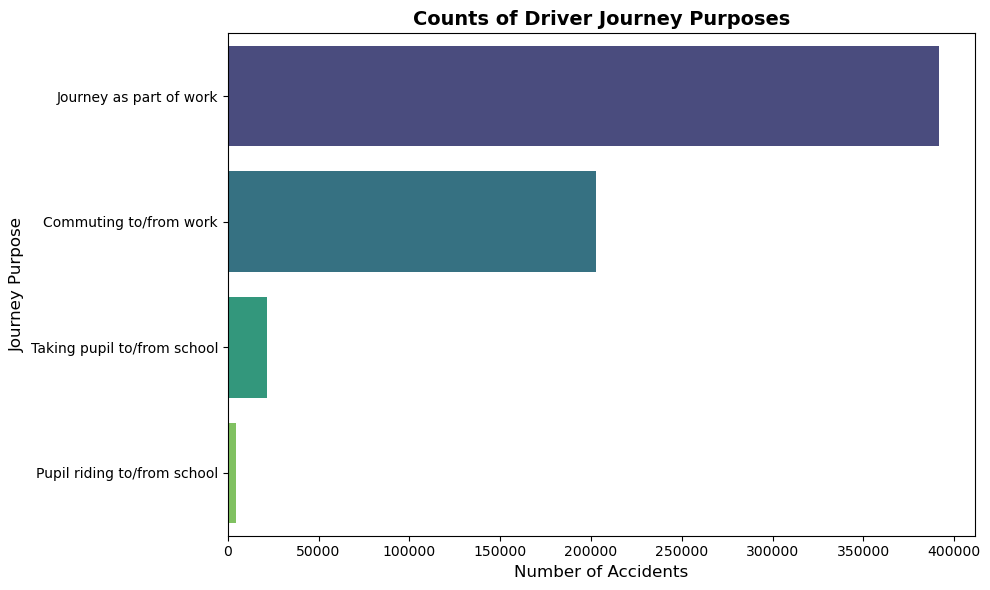

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=purpose_counts.values, y=purpose_counts.index, palette="viridis"
)

plt.title("Counts of Driver Journey Purposes", fontsize=14, fontweight="bold")
plt.xlabel("Number of Accidents", fontsize=12)
plt.ylabel("Journey Purpose", fontsize=12)

plt.tight_layout()
plt.show()

There is a lot of data where the reason for the person's journey is not known or not recorded. So I filtered out those values and looked for the values that stated actual reasons towards journey. We see most reasons for using a vehichle was either apart of work or commuting to work. The least being a pupil is riding to and from school. With the data we have on journey purpose we see driving for work can cause the most accidents. It's less likely for people to work on Sunday's which can contribute to why Sundays have the lowest accident records. 

### Severity of Accidents Over Time 

In [ ]:
acc_data["Date"] = pd.to_datetime(acc_data["Date"])

In [ ]:
acc_data.groupby([acc_data["Date"], "Accident_Severity"]).size().reset_index(name="accident_count")

,Date,Accident_Severity,accident_count
0,2005-01-01,Fatal,8
1,2005-01-01,Serious,54
2,2005-01-01,Slight,246
3,2005-01-02,Fatal,4
4,2005-01-02,Serious,47
...,...,...,...
14183,2017-12-30,Serious,46
14184,2017-12-30,Slight,161
14185,2017-12-31,Fatal,5
14186,2017-12-31,Serious,33


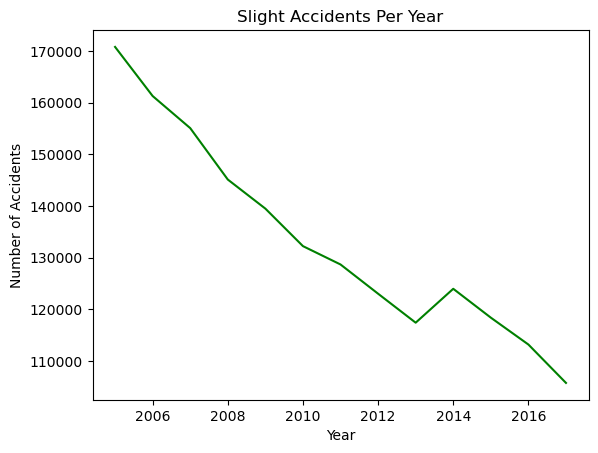

In [ ]:
slight_df = acc_data[acc_data["Accident_Severity"] == "Slight"]

slight_by_year = slight_df.groupby(slight_df["Date"].dt.year).size()


slight_by_year.plot(color="green")
plt.title("Slight Accidents Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

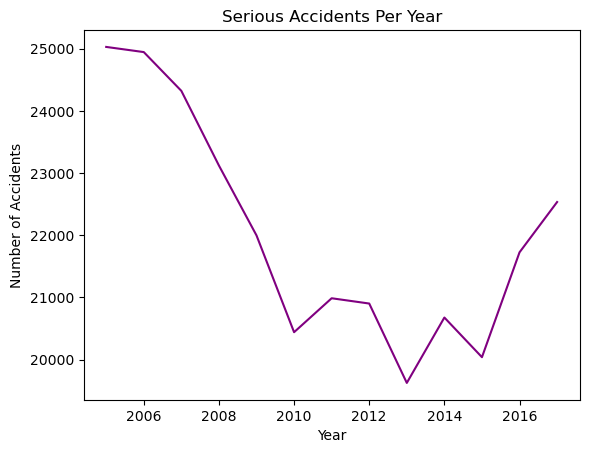

In [ ]:
serious_df = acc_data[acc_data["Accident_Severity"] == "Serious"]

serious_by_year = serious_df.groupby(serious_df["Date"].dt.year).size()


serious_by_year.plot(color="purple")
plt.title("Serious Accidents Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

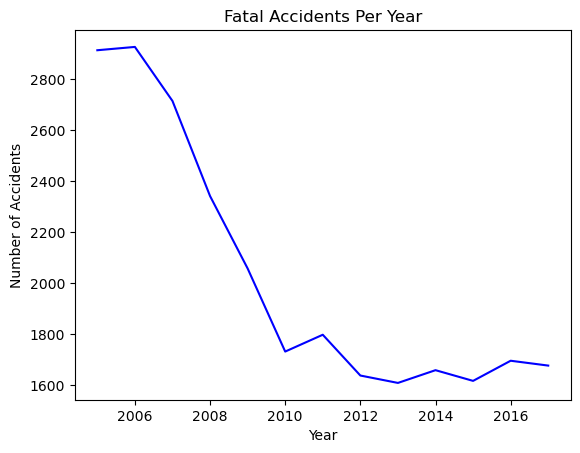

In [ ]:
fatal_df = acc_data[acc_data["Accident_Severity"] == "Fatal"]

fatal_by_year = fatal_df.groupby(fatal_df["Date"].dt.year).size()


fatal_by_year.plot(color="blue")
plt.title("Fatal Accidents Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

The slight accidents per year dropped from 2006 to 2013, then we see a slight increase from 2013 - 2014 and then a drop after 2014. 

The serious accidents over the years dropped after 2006 but then we see a constant drop and rise from 2010 to 2016, with an increase after 2016. 

In terms of fatal accidents per year, we see a stagnation from 2006, then a drop until 2010. After 2010 we see slight drops and rises but less steepness. 

Based on these findings we can look at other factors that may contribute to these accident rates. Vehicles have drastically improved over the years to create features that help reduce accidents. 

### Weather Conditions v Accidents 

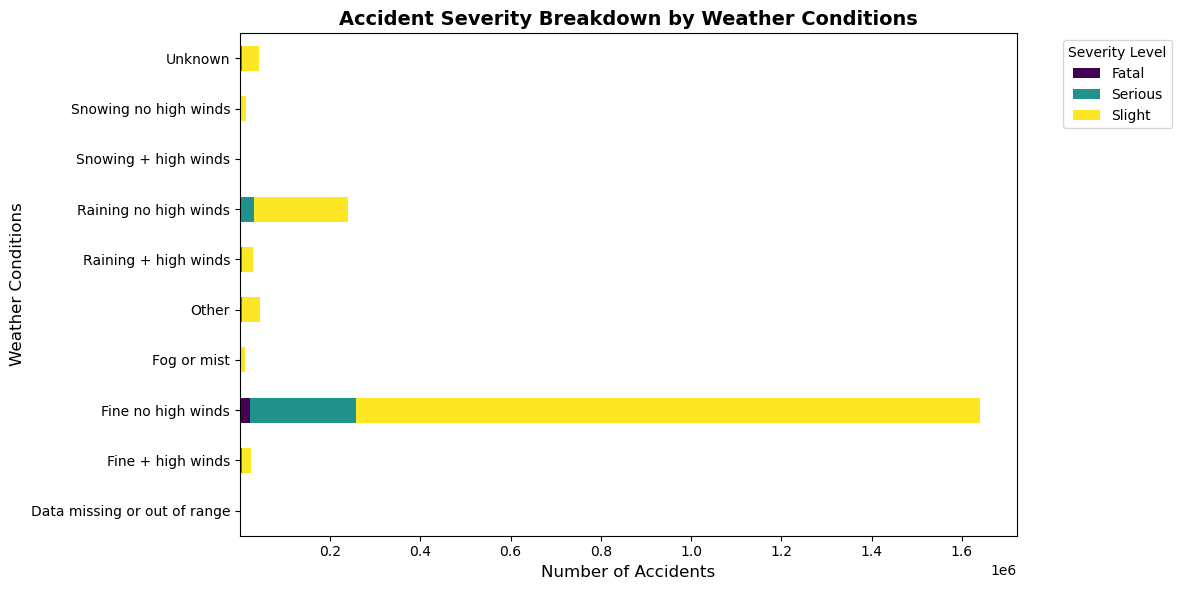

In [34]:
weather_severity_counts = pd.crosstab(
    acc_data["Weather_Conditions"], acc_data["Accident_Severity"]
)

weather_severity_counts.plot(
    kind="barh", stacked=True, figsize=(12, 6), colormap="viridis"
)

plt.title(
    "Accident Severity Breakdown by Weather Conditions",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of Accidents", fontsize=12)
plt.ylabel("Weather Conditions", fontsize=12)
plt.legend(title="Severity Level", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [32]:
weather_severity_counts = pd.crosstab(
    acc_data["Weather_Conditions"], acc_data["Accident_Severity"]
)

weather_severity_counts

Accident_Severity,Fatal,Serious,Slight
Weather_Conditions,,,
Data missing or out of range,5,13,157
Fine + high winds,481,3925,21410
Fine no high winds,21818,235890,1382387
Fog or mist,238,1643,9187
Other,398,5058,38627
Raining + high winds,400,3920,24023
Raining no high winds,2540,30053,206688
Snowing + high winds,15,295,2177
Snowing no high winds,110,1348,11929


This data result is interesting as you would expect high accident rates to occur during weather conditions that are hard to drive in. However, it's more likley for people to use their car during fine/clear weather than snowy or rainy whether, hence why the severity rate for 'Fine no high winds' is so high. More people will be using vehicles/ transportation when the whether is clear. Apart from the data that is unknown, we see conditions like 'Snowing + high winds' and 'Fog or mist' having less accident severity records than Raining or Fine conditions.

### Urban or Rural vs Accidents

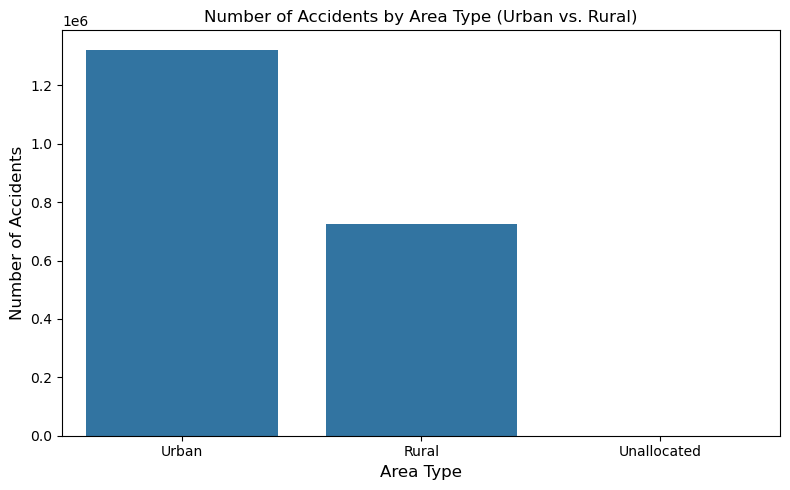

Accident Counts
Urban_or_Rural_Area
Urban          1322339
Rural           724757
Unallocated        160
Name: count, dtype: int64


In [33]:
area_counts = acc_data["Urban_or_Rural_Area"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(x=area_counts.index, y=area_counts.values)

plt.title(
    "Number of Accidents by Area Type (Urban vs. Rural)"
)
plt.xlabel("Area Type", fontsize=12)
plt.ylabel("Number of Accidents", fontsize=12)

plt.tight_layout()
plt.show()

print("Accident Counts")
print(area_counts)

There's a clear difference between accident amounts in urban areas and accident amounts in rural areas. Rural areas are more likely to have less traffic, less roads/lanes, yet there's still a large amount of accidents (700k+). Urban areas have over 1 million accident records. Because road experience is different between urban and rural areas, town planners may have to promote road safety procedures more based on the type of area they're dealing with. Unallocated could be Suburban, extremely secluded areas, or that the data behind area is unknown. 